# Employee Burnout — ML  Project

This notebook covers:
- Regression: predicting **Burn Rate**
- Classification: predicting **High Burnout** (Burn Rate >= threshold)

In [72]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_validate, cross_val_score, GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Load Data
The dataset is expected to be available in Kaggle under `/kaggle/input`.


In [74]:
# Find train.csv inside /kaggle/input (typical Kaggle setup)
DATA_PATH = None
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        if filename.lower() == "train.csv":
            DATA_PATH = os.path.join(dirname, filename)
            break
    if DATA_PATH:
        break

# Fallback: if running locally and train.csv is in the working directory
if DATA_PATH is None:
    if os.path.exists("train.csv"):
        DATA_PATH = "train.csv"
    else:
        raise FileNotFoundError("train.csv not found in /kaggle/input or local working directory.")

print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)

display(df.head())
print("Shape:", df.shape)


Loading: /kaggle/input/hackerearth-employee-burnout-challenge/train.csv


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


Shape: (22750, 9)


## Data Cleaning & Feature Engineering
- Drop rows without **Burn Rate** (target for regression).
- Convert **Date of Joining** into **Join_Year**, then drop the original date column.


In [75]:
df = df.dropna(subset=["Burn Rate"]).copy()

if "Date of Joining" in df.columns:
    df["Date of Joining"] = pd.to_datetime(df["Date of Joining"], errors="coerce")
    df["Join_Year"] = df["Date of Joining"].dt.year
    df = df.drop(columns=["Date of Joining"])

missing = df.isna().sum().sort_values(ascending=False)
display(missing.head(15))
print("Shape after cleaning:", df.shape)


Mental Fatigue Score    1945
Resource Allocation     1278
Employee ID                0
Gender                     0
Company Type               0
WFH Setup Available        0
Designation                0
Burn Rate                  0
Join_Year                  0
dtype: int64

Shape after cleaning: (21626, 9)


Cleaning

Drop missing Burn Rate (no target = no training).

Date → Join_Year (simple numeric signal).

## Train/Test Split + Preprocessing
- **X**: features (without Burn Rate and Employee ID)
- **y_reg**: Burn Rate (regression target)
- Numeric: median imputation + scaling  
- Categorical: most frequent imputation + one-hot encoding


In [77]:
TARGET = "Burn Rate"
DROP_COLS = [c for c in ["Employee ID"] if c in df.columns]

y_reg = df[TARGET].copy()
X = df.drop(columns=[TARGET] + DROP_COLS).copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocess, num_cols),
        ("cat", categorical_preprocess, cat_cols),
    ],
    remainder="drop",
)


Numeric columns: ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Join_Year']
Categorical columns: ['Gender', 'Company Type', 'WFH Setup Available']


Split X/y, drop Employee ID (identifier only).

Numeric: impute + scale.

Categorical: impute + one-hot.

Pipeline = consistent, no leakage.

## Part A — Regression
We predict **Burn Rate** using a linear regression model inside a pipeline.


### Cross-validation
Note: `neg_root_mean_squared_error` returns negative values in scikit-learn,
so we flip the sign to get the actual RMSE.


In [78]:
reg_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression()),
])

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores = cross_validate(
    reg_model, X, y_reg,
    cv=cv_reg,
    scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
    return_train_score=True,
)

rmse_val = -scores["test_rmse"]
r2_val = scores["test_r2"]
rmse_train = -scores["train_rmse"]
r2_train = scores["train_r2"]

print(f"CV RMSE (val): {rmse_val.mean():.6f} +/- {rmse_val.std():.6f}")
print(f"CV R2   (val): {r2_val.mean():.6f} +/- {r2_val.std():.6f}")
print(f"RMSE (train): {rmse_train.mean():.6f}")
print(f"R2   (train): {r2_train.mean():.6f}")


CV RMSE (val): 0.071349 +/- 0.000713
CV R2   (val): 0.870409 +/- 0.002482
RMSE (train): 0.071323
R2   (train): 0.870530


Cross-validation (Linear Regression)

Use K-Fold CV to estimate performance more reliably than one split.

Report RMSE + R² to measure error size and explained variance.

### Holdout Test + Baseline
Compare the model to a simple baseline that always predicts the mean of the training target.


In [79]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

reg_model.fit(X_train_reg, y_train_reg)
y_pred = reg_model.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print(f"MSE: {mse:.6f}")
print(f"R2 : {r2:.6f}")

baseline_pred = np.full(shape=len(y_test_reg), fill_value=y_train_reg.mean())
baseline_mse = mean_squared_error(y_test_reg, baseline_pred)

print(f"Baseline MSE (mean predictor): {baseline_mse:.6f}")
print("Model better than baseline:", mse < baseline_mse)


MSE: 0.005031
R2 : 0.867923
Baseline MSE (mean predictor): 0.038089
Model better than baseline: True


Holdout RMSE: 0.0709
Holdout MAE : 0.0535
Holdout R^2 : 0.8679

Top 15 features by absolute coefficient value:


,feature,coef,abs_coef
2,Mental Fatigue Score,0.123386,0.123386
1,Resource Allocation,0.062433,0.062433
0,Designation,0.009963,0.009963
9,WFH Setup Available_Yes,-0.008519,0.008519
8,WFH Setup Available_No,0.008519,0.008519
4,Gender_Female,-0.003135,0.003135
5,Gender_Male,0.003135,0.003135
7,Company Type_Service,0.000159,0.000159
6,Company Type_Product,-0.000159,0.000159
3,Join_Year,0.000000,0.000000


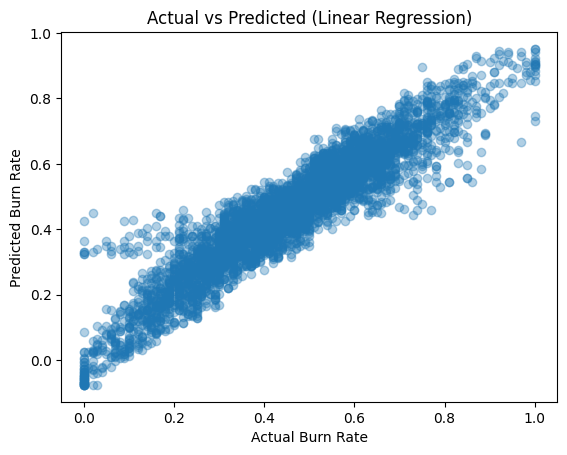

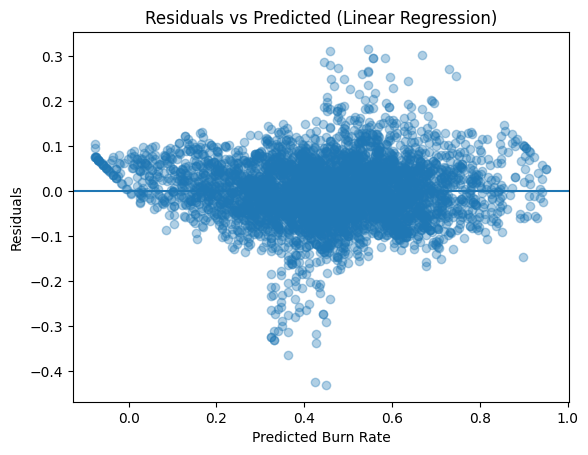

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Holdout metrics ---
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
mae  = mean_absolute_error(y_test_reg, y_pred)
r2   = r2_score(y_test_reg, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout MAE : {mae:.4f}")
print(f"Holdout R^2 : {r2:.4f}")

# --- Linear Regression coefficients (feature effects) ---
pre = reg_model.named_steps["preprocess"]
lin = reg_model.named_steps["model"]

# These should already exist in your notebook:
# num_cols = [...]
# cat_cols = [...]

ohe = pre.named_transformers_["cat"].named_steps["onehot"]
feature_names = np.r_[num_cols, ohe.get_feature_names_out(cat_cols)]
coef = lin.coef_

coef_df = (
    pd.DataFrame({"feature": feature_names, "coef": coef})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

print("\nTop 15 features by absolute coefficient value:")
display(coef_df.head(15))

# --- Diagnostics plots ---
plt.figure()
plt.scatter(y_test_reg, y_pred, alpha=0.35)
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

residuals = y_test_reg - y_pred
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.35)
plt.axhline(0)
plt.xlabel("Predicted Burn Rate")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Linear Regression)")
plt.show()


### Holdout test + baseline

Test on a separate holdout set to check generalization.

Compare vs mean baseline to prove the model adds value (it beats baseline).

### Coefficients (feature effects)

Print top absolute coefficients to see which inputs impact Burn Rate most (direction = increase/decrease)

### Plots

Actual vs Predicted: points close to diagonal = good fit.

Residuals vs Predicted: ideally random around 0; patterns suggest non-linearity / heteroscedasticity.

## Part B — Classification
We create a binary label:
- `1` if Burn Rate >= threshold
- `0` otherwise

Then we train classification models and evaluate with ROC-AUC.


### Label Definition + Split
We use a **stratified** split to keep class proportions similar in train and test.


In [80]:
THRESHOLD = 0.5
y_clf = (df["Burn Rate"] >= THRESHOLD).astype(int)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

print("Train class distribution:")
display(pd.Series(y_train_clf).value_counts(normalize=True))

print("Test class distribution:")
display(pd.Series(y_test_clf).value_counts(normalize=True))


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Train class distribution:


Burn Rate
0    0.582543
1    0.417457
Name: proportion, dtype: float64

Test class distribution:


Burn Rate
0    0.582524
1    0.417476
Name: proportion, dtype: float64

### Baseline (DummyClassifier)
A simple baseline that always predicts the most frequent class.


In [81]:
dummy = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)),
])

dummy.fit(X_train_clf, y_train_clf)
dummy_prob = dummy.predict_proba(X_test_clf)[:, 1]
print("Dummy ROC-AUC:", roc_auc_score(y_test_clf, dummy_prob))


Dummy ROC-AUC: 0.5


Most-frequent baseline gives a reference ROC-AUC (~0.5 = random), so we know if real models actually learn.

### Logistic Regression
We report:
- CV ROC-AUC
- Test ROC-AUC
- Confusion matrix and classification report
- ROC curve plot


CV ROC-AUC: 0.978679 +/- 0.001838
Accuracy: 0.9197873324086916
Test ROC-AUC: 0.979020438924924
Confusion matrix:
 [[2359  161]
 [ 186 1620]]

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.94      0.93      2520
           1       0.91      0.90      0.90      1806

    accuracy                           0.92      4326
   macro avg       0.92      0.92      0.92      4326
weighted avg       0.92      0.92      0.92      4326



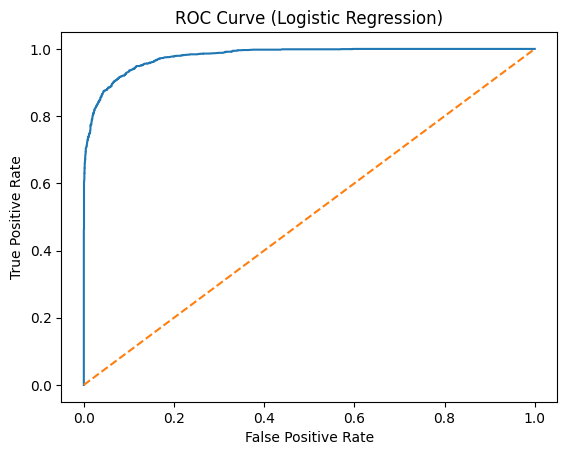

In [82]:
clf_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

auc_scores = cross_val_score(clf_logreg, X, y_clf, cv=cv_clf, scoring="roc_auc")
print(f"CV ROC-AUC: {auc_scores.mean():.6f} +/- {auc_scores.std():.6f}")

clf_logreg.fit(X_train_clf, y_train_clf)

y_prob = clf_logreg.predict_proba(X_test_clf)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test_clf, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test_clf, y_prob))
print("Confusion matrix:\n", confusion_matrix(y_test_clf, y_pred))
print("\nClassification report:\n", classification_report(y_test_clf, y_pred))

fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.show()


Train a simple interpretable classifier and evaluate with ROC-AUC (good for probability ranking).

Also report accuracy + confusion matrix + classification report to see precision/recall trade-offs.

ROC curve far above diagonal = strong separation.

### KNN: Baseline + Tuning
- Baseline KNN with `k=5`
- Hyperparameter tuning with GridSearchCV (ROC-AUC)
- Final evaluation on the same test split


In [83]:
knn_baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="uniform")),
])

knn_baseline.fit(X_train_clf, y_train_clf)
pred_base = knn_baseline.predict(X_test_clf)
proba_base = knn_baseline.predict_proba(X_test_clf)[:, 1]

print("KNN baseline accuracy:", accuracy_score(y_test_clf, pred_base))
print("KNN baseline ROC-AUC :", roc_auc_score(y_test_clf, proba_base))


KNN baseline accuracy: 0.9158576051779935
KNN baseline ROC-AUC : 0.9618833386067606


Best params: {'model__n_neighbors': 29, 'model__weights': 'uniform'}
Best CV ROC-AUC: 0.9771554191789653
Tuned KNN accuracy: 0.9230235783633842
Tuned KNN ROC-AUC : 0.9795193271106892
Confusion matrix:
 [[2384  136]
 [ 197 1609]]

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.93      2520
           1       0.92      0.89      0.91      1806

    accuracy                           0.92      4326
   macro avg       0.92      0.92      0.92      4326
weighted avg       0.92      0.92      0.92      4326



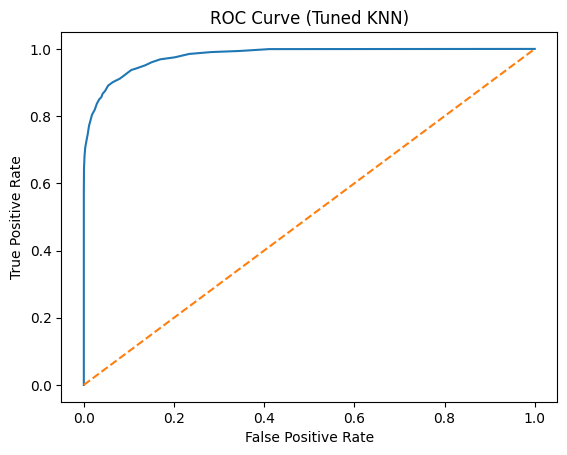

In [84]:
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier()),
])

param_grid = {
    "model__n_neighbors": list(range(3, 31, 2)),
    "model__weights": ["uniform", "distance"],
}

grid = GridSearchCV(
    knn_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_clf,
    n_jobs=-1,
)

grid.fit(X_train_clf, y_train_clf)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

best_knn = grid.best_estimator_
pred = best_knn.predict(X_test_clf)
prob = best_knn.predict_proba(X_test_clf)[:, 1]

print("Tuned KNN accuracy:", accuracy_score(y_test_clf, pred))
print("Tuned KNN ROC-AUC :", roc_auc_score(y_test_clf, prob))
print("Confusion matrix:\n", confusion_matrix(y_test_clf, pred))
print("\nClassification report:\n", classification_report(y_test_clf, pred))

fpr, tpr, _ = roc_curve(y_test_clf, prob)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Tuned KNN)")
plt.show()


KNN is distance-based, so scaling in preprocessing is important.

Use GridSearchCV to tune n_neighbors (and weights) to improve ROC-AUC.

Compare tuned KNN vs Logistic Regression to see if non-linear boundaries help.